# NYC PLUTO — Exploratory Valuation Analysis (Staten Island + Brooklyn)

First pass at the **valuation / relative-value** layer. We treat NYC PLUTO as the authoritative
record for each tax lot and look for **under-built lots** — where the built floor-area-ratio (FAR)
is far below the maximum the zoning allows. A big gap = unused air rights = development upside.

Data lives in the indexed `nyc_pluto_lot` table (SQLite, keyed by BBL), loaded via
`flaskblog.pluto.load_pluto(('SI','BK'))`. Metric definitions mirror `flaskblog/ranking/pluto.py`
so the notebook and the app agree.

No Google Maps / paid APIs are used here — PLUTO ships its own coordinates.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from flaskblog import app, db
from flaskblog.models import NycPlutoLot
from flaskblog.pluto import load_pluto

ctx = app.app_context(); ctx.push()  # keep an app context alive for the notebook

# Load SI+BK if the table is empty (idempotent; safe to re-run).
if NycPlutoLot.query.count() == 0:
    print('Loading Staten Island + Brooklyn from NYC Open Data...')
    print(load_pluto(('SI', 'BK')))

df = pd.read_sql(db.session.query(NycPlutoLot).statement, db.engine)
print(f'{len(df):,} lots loaded')
df['borough'].value_counts()

402,003 lots loaded


borough
BK    276311
SI    125692
Name: count, dtype: int64

## 1. Field-coverage profile

Which columns can we trust? For each curated field, the share that is non-null, plus basic
stats for the numeric ones. `bldg_area`/`built_far` near zero is expected for vacant land.

In [2]:
coverage = pd.DataFrame({
    'non_null_%': (df.notna().mean() * 100).round(1),
    'n_non_null': df.notna().sum(),
}).sort_values('non_null_%', ascending=False)
coverage

,non_null_%,n_non_null
bbl,100.0,402003
borough,100.0,402003
block,100.0,402003
lot,100.0,402003
address,100.0,401819
bldg_area,100.0,401846
units_total,100.0,401813
units_res,100.0,401813
pluto_version,100.0,402003
facil_far,100.0,402003


In [3]:
num_cols = ['lot_area', 'bldg_area', 'built_far', 'resid_far', 'comm_far',
            'facil_far', 'num_floors', 'year_built', 'assess_tot']
df[num_cols].describe().T[['count', 'mean', '50%', 'min', 'max']]

,count,mean,50%,min,max
lot_area,401737.0,7565.487899,2500.00,0.0,2.073912e+08
bldg_area,401846.0,4616.716454,2114.00,0.0,2.400000e+07
built_far,401636.0,1.038424,0.83,0.0,2.145200e+02
resid_far,402003.0,1.407040,1.00,0.0,1.500000e+01
comm_far,402003.0,0.117158,0.00,0.0,1.500000e+01
facil_far,402003.0,2.131520,2.00,0.0,1.500000e+01
num_floors,381082.0,2.329963,2.00,0.0,3.428700e+02
year_built,401860.0,1847.337222,1930.00,0.0,2.025000e+03
assess_tot,401860.0,320548.318255,68940.00,0.0,1.549967e+09


## 2. FAR distributions

`max_far` = the greatest of the residential / commercial / community-facility FARs (what the
zoning allows). `pct_far_used` = `built_far / max_far`: near **0** = heavily under-built,
**1** = built to the max, **>1** = over-built (e.g. grandfathered).

In [4]:
# Vectorized versions of flaskblog/ranking/pluto.py metrics.
df['max_far'] = df[['resid_far', 'comm_far', 'facil_far']].max(axis=1)

buildable = (df['max_far'] * df['lot_area'] - df['bldg_area'].fillna(0)).clip(lower=0)
df['buildable_sqft_remaining'] = buildable

valid_far = (df['max_far'] > 0) & df['built_far'].notna()
df['pct_far_used'] = (df['built_far'] / df['max_far']).where(valid_far)

df[['built_far', 'max_far', 'pct_far_used', 'buildable_sqft_remaining']].describe().T

,count,mean,std,min,25%,50%,75%,max
built_far,401636.0,1.038424,0.998321,0.0,0.5200,0.830,1.34,2.145200e+02
max_far,402003.0,2.145120,1.341266,0.0,1.0000,2.000,2.00,1.500000e+01
pct_far_used,399647.0,0.524439,0.398859,0.0,0.3125,0.475,0.66,8.855000e+01
buildable_sqft_remaining,401737.0,8031.583941,247643.930793,0.0,1148.0000,2316.000,4387.00,1.262206e+08


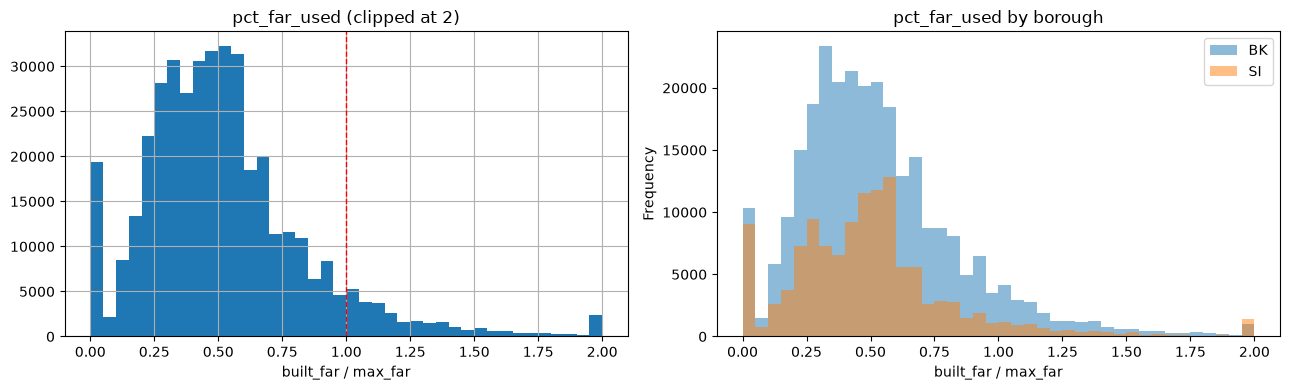

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['pct_far_used'].clip(0, 2).hist(bins=40, ax=axes[0])
axes[0].set_title('pct_far_used (clipped at 2)'); axes[0].set_xlabel('built_far / max_far')
axes[0].axvline(1.0, color='red', ls='--', lw=1)

for boro, sub in df.groupby('borough'):
    sub['pct_far_used'].clip(0, 2).plot(kind='hist', bins=40, alpha=0.5, ax=axes[1], label=boro)
axes[1].set_title('pct_far_used by borough'); axes[1].set_xlabel('built_far / max_far'); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Under-built lots — the development-upside ranking

The headline output: lots with lots of **unused buildable area**, ranked by remaining
buildable square footage. This uses the shared `UnderbuiltInfillScorer` from
`flaskblog/ranking/scorers.py` — the *same* selection + ranking policy the app uses, so the
notebook and production never drift.

**Why a scorer (and not a naive rank):** ranking purely by `max_far * lot_area - bldg_area` is
dominated by mega-parcels that will never be redeveloped — cemeteries (e.g. Green-Wood), parks,
wetlands, transit yards. `UnderbuiltInfillScorer` filters to **realistic infill**:
developable land uses (PLUTO `land_use` 01–06, 11), a developable footprint (`2,000–20,000` sqft),
genuinely under-built (`pct_far_used < 0.5`), and **not** government/authority-owned.

In [6]:
from flaskblog.ranking.scorers import UnderbuiltInfillScorer

scorer = UnderbuiltInfillScorer()  # defaults: 2k-20k sqft lots, <50% FAR used
scored = scorer.rank(limit=50, boroughs=('SI', 'BK'))

top = pd.DataFrame([s.as_row() for s in scored])
print(f'{len(scored)} scored infill lots (showing all up to 50):')
top

50 scored infill lots (showing all up to 50):


,bbl,borough,address,zone_dist1,land_use,lot_area,bldg_area,built_far,max_far,pct_far_used,buildable_sqft_remaining,assess_tot,score
0,3001540019,BK,380 FULTON STREET,C6-4.5,11,11246,0,0.0,12.00,0.0,134952.00,819000,134952.00
1,3002550014,BK,REMSEN STREET,C5-2A,11,13311,0,0.0,10.00,0.0,133110.00,2725650,133110.00
2,3004660060,BK,413 BOND STREET,M1-4,11,19800,0,0.0,6.50,0.0,128700.00,735300,128700.00
3,3025380038,BK,0 JAVA STREET,R8,11,18451,0,0.0,6.50,0.0,119931.50,252480,119931.50
4,3023400010,BK,NORTH 5 STREET,R8,11,18220,0,0.0,6.50,0.0,118430.00,8400,118430.00
5,3025700045,BK,75 WHARF DRIVE,R8,11,16473,0,0.0,6.50,0.0,107074.50,2240550,107074.50
6,3001490030,BK,FULTON STREET,C6-4.5,11,8837,0,0.0,12.00,0.0,106044.00,2123550,106044.00
7,3001540005,BK,356 FULTON STREET,C6-4.5,11,8644,0,0.0,12.00,0.0,103728.00,1987200,103728.00
8,3024820009,BK,19 CLAY STREET,M1-2/R6,11,19747,0,0.0,4.80,0.0,94785.60,319950,94785.60
9,3035180046,BK,482 THOMAS S BOYLAND,R6,11,19673,0,0.0,4.80,0.0,94430.40,96900,94430.40


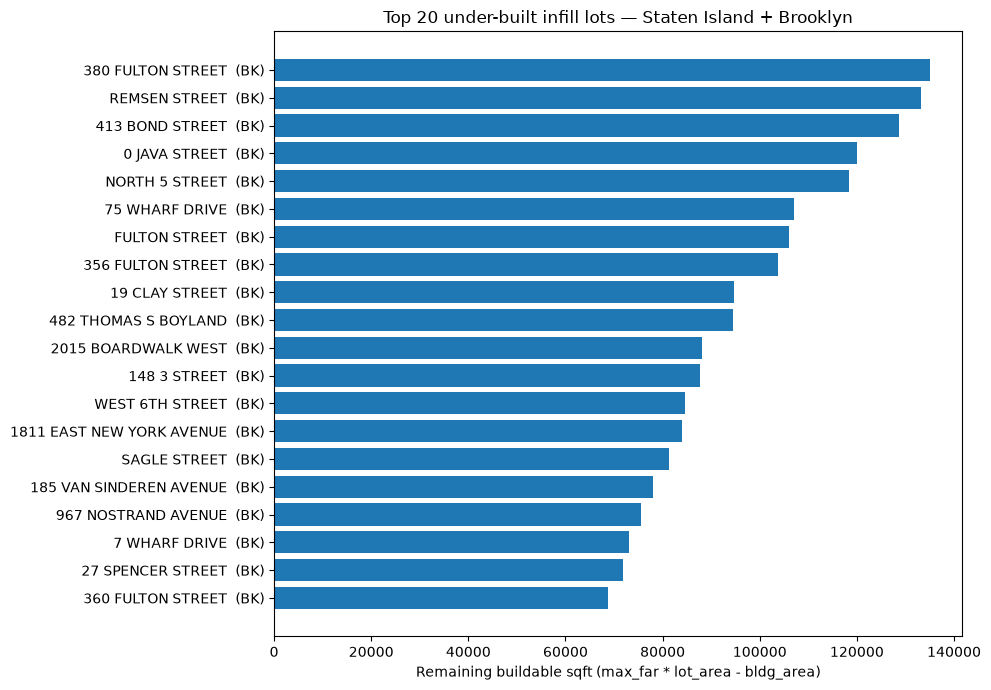

In [7]:
top20 = top.head(20).iloc[::-1]
labels = top20['address'].fillna(top20['bbl']).str.slice(0, 28) + '  (' + top20['borough'] + ')'
plt.figure(figsize=(10, 7))
plt.barh(labels, top20['buildable_sqft_remaining'])
plt.xlabel('Remaining buildable sqft (max_far * lot_area - bldg_area)')
plt.title('Top 20 under-built infill lots — Staten Island + Brooklyn')
plt.tight_layout(); plt.show()

### Next steps
- Cross-reference these BBLs against live listings (needs the scraper to capture street
  addresses + sqft) to compute **$/buildable-sqft** and flag **listing-vs-record discrepancies**
  via `flaskblog.ranking.pluto.sqft_discrepancy`.
- Widen the load to all five boroughs: `load_pluto(None)`.
- Refine `max_far`: for a purely residential development, `resid_far` (not the max across uses)
  is the right ceiling — worth a use-aware variant.